In [2]:
import pandas as pd

df = pd.read_csv("/content/SWYNEX_Online_Retail_Cleaned (1).csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False


In [4]:
df.shape

(536638, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536638 entries, 0 to 536637
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   InvoiceNo       536638 non-null  object 
 1   StockCode       536638 non-null  object 
 2   Description     535183 non-null  object 
 3   Quantity        536638 non-null  int64  
 4   InvoiceDate     536638 non-null  object 
 5   UnitPrice       536638 non-null  float64
 6   CustomerID      401604 non-null  float64
 7   Country         536638 non-null  object 
 8   IsCancellation  536638 non-null  bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 33.3+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,536638.000000,536638.000000,401604.000000
mean,9.620077,4.653295,15281.160818
std,219.130768,93.648553,1714.006089
min,-80995.000000,0.000000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1455
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135034
Country,0
IsCancellation,0


In [8]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Description,1455
CustomerID,135034


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='object').columns

print("Numerical columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['Quantity', 'UnitPrice', 'CustomerID']

Categorical columns:
['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

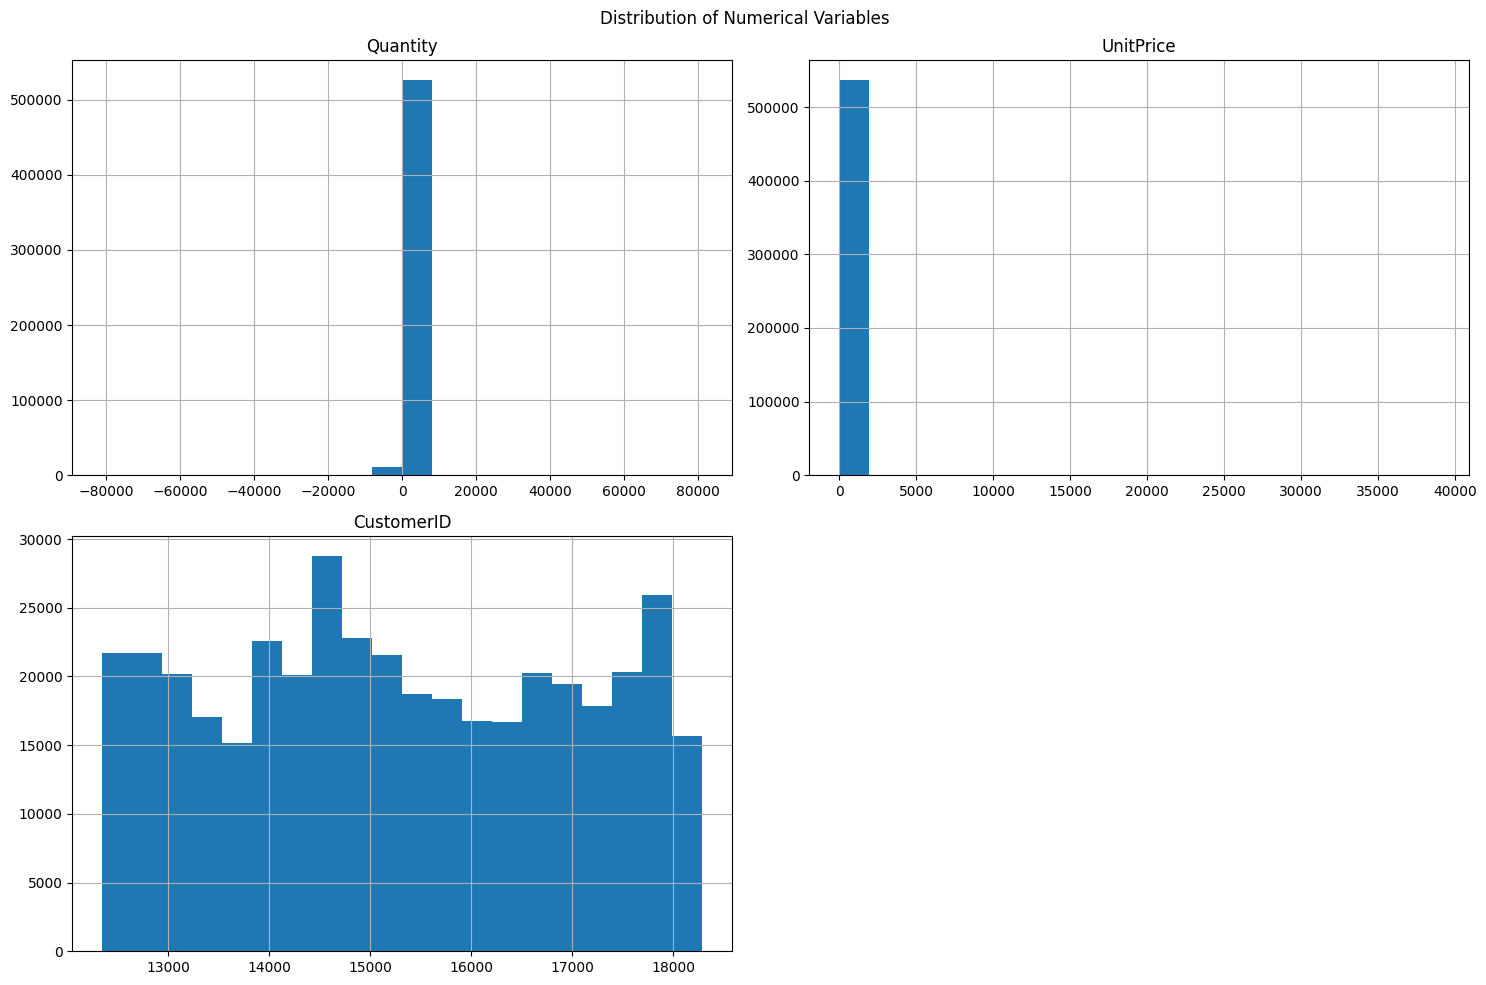

In [12]:
df[numeric_cols].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

In [14]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'IsCancellation']


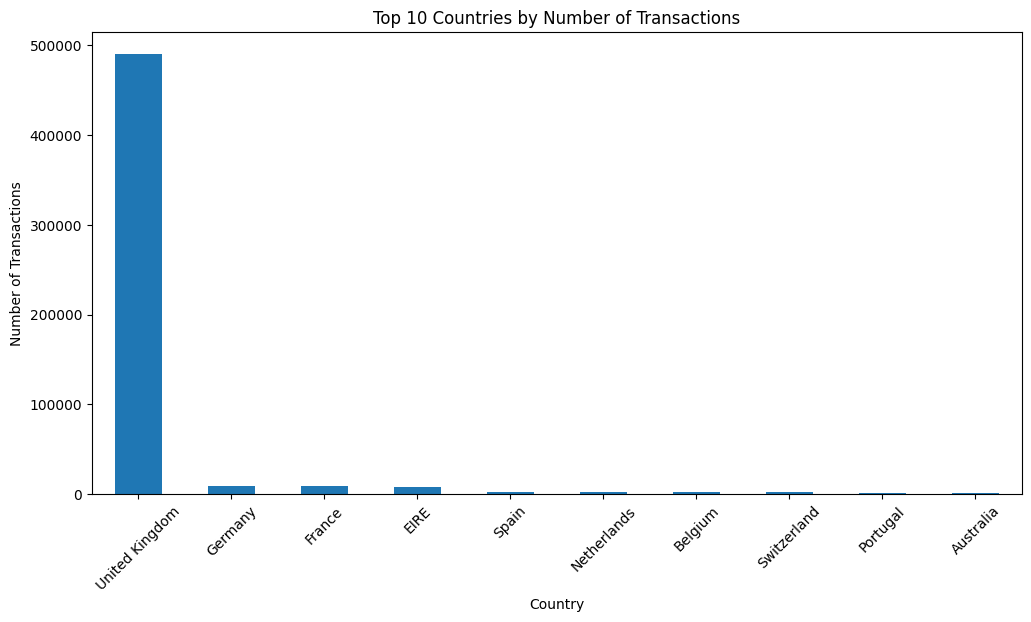

In [15]:
plt.figure(figsize=(12, 6))

country_counts = df['Country'].value_counts().head(10)

country_counts.plot(kind='bar')

plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()

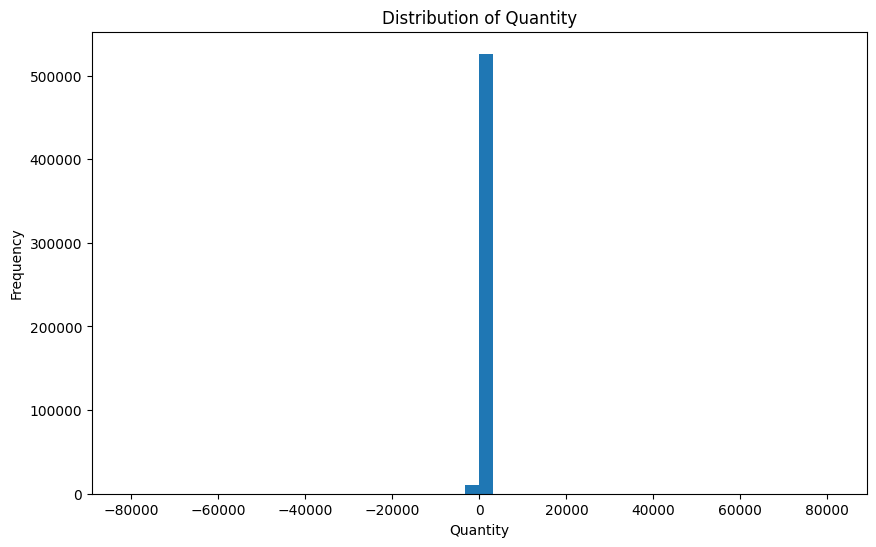

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(df['Quantity'], bins=50)

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

In [17]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[
    (df['Quantity'] < lower_bound) |
    (df['Quantity'] > upper_bound)
]

print("\nNumber of outliers:", len(outliers))

Q1: 1.0
Q3: 10.0
IQR: 9.0
Lower Bound: -12.5
Upper Bound: 23.5

Number of outliers: 58501


In [18]:
negative_quantity = df[df['Quantity'] < 0]

print("Number of negative quantity records:", len(negative_quantity))
print("\nSample negative quantity records:")
print(negative_quantity[['InvoiceNo', 'Description', 'Quantity', 'Country', 'IsCancellation']].head(10))

Number of negative quantity records: 10587

Sample negative quantity records:
    InvoiceNo                       Description  Quantity         Country  \
141   C536379                          DISCOUNT        -1  United Kingdom   
154   C536383   SET OF 3 COLOURED  FLYING DUCKS        -1  United Kingdom   
235   C536391     PLASTERS IN TIN CIRCUS PARADE       -12  United Kingdom   
236   C536391   PACK OF 12 PINK PAISLEY TISSUES       -24  United Kingdom   
237   C536391   PACK OF 12 BLUE PAISLEY TISSUES       -24  United Kingdom   
238   C536391  PACK OF 12 RED RETROSPOT TISSUES       -24  United Kingdom   
239   C536391       CHICK GREY HOT WATER BOTTLE       -12  United Kingdom   
240   C536391   PLASTERS IN TIN VINTAGE PAISLEY       -12  United Kingdom   
241   C536391            PLASTERS IN TIN SKULLS       -24  United Kingdom   
916   C536506          JAM MAKING SET WITH JARS        -6  United Kingdom   

     IsCancellation  
141            True  
154            True  
235     

In [19]:
cancellation_quantity = pd.crosstab(
    df['IsCancellation'],
    df['Quantity'] < 0
)

print(cancellation_quantity)

Quantity         False  True 
IsCancellation               
False           526051   1336
True                 0   9251


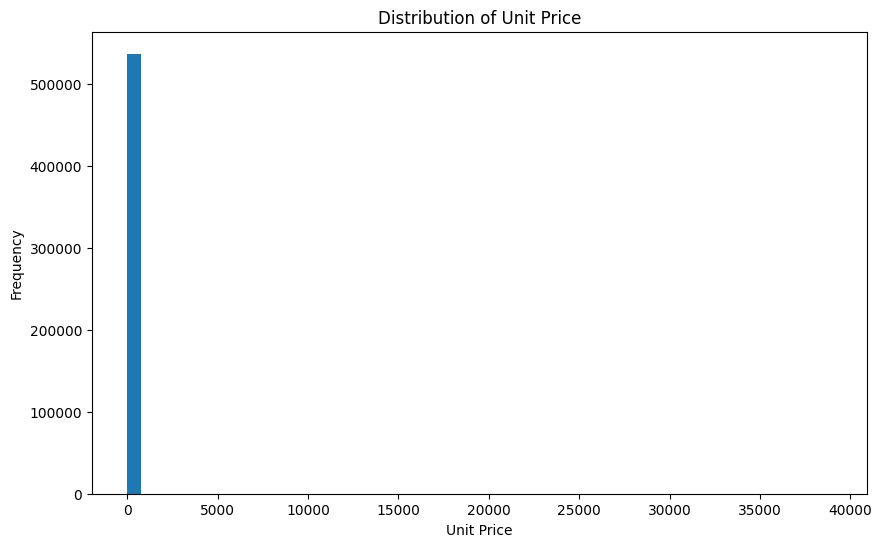

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(df['UnitPrice'], bins=50)

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.show()

In [21]:
Q1_price = df['UnitPrice'].quantile(0.25)
Q3_price = df['UnitPrice'].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower Bound:", lower_price)
print("Upper Bound:", upper_price)

price_outliers = df[
    (df['UnitPrice'] < lower_price) |
    (df['UnitPrice'] > upper_price)
]

print("\nNumber of UnitPrice outliers:", len(price_outliers))

Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower Bound: -3.0700000000000003
Upper Bound: 8.45

Number of UnitPrice outliers: 39447


In [22]:
top_prices = df[
    ['Description', 'UnitPrice', 'Quantity', 'Country']
].sort_values(
    by='UnitPrice',
    ascending=False
).head(10)

top_prices

,Description,UnitPrice,Quantity,Country
220826,MANUAL,38970.00,-1,United Kingdom
519494,AMAZON FEE,17836.46,-1,United Kingdom
43193,AMAZON FEE,16888.02,-1,United Kingdom
43194,AMAZON FEE,16453.71,-1,United Kingdom
16087,AMAZON FEE,13541.33,-1,United Kingdom
14757,AMAZON FEE,13541.33,1,United Kingdom
14756,AMAZON FEE,13541.33,-1,United Kingdom
15972,AMAZON FEE,13474.79,-1,United Kingdom
519493,AMAZON FEE,11586.50,-1,United Kingdom
442654,AMAZON FEE,8286.22,-1,United Kingdom


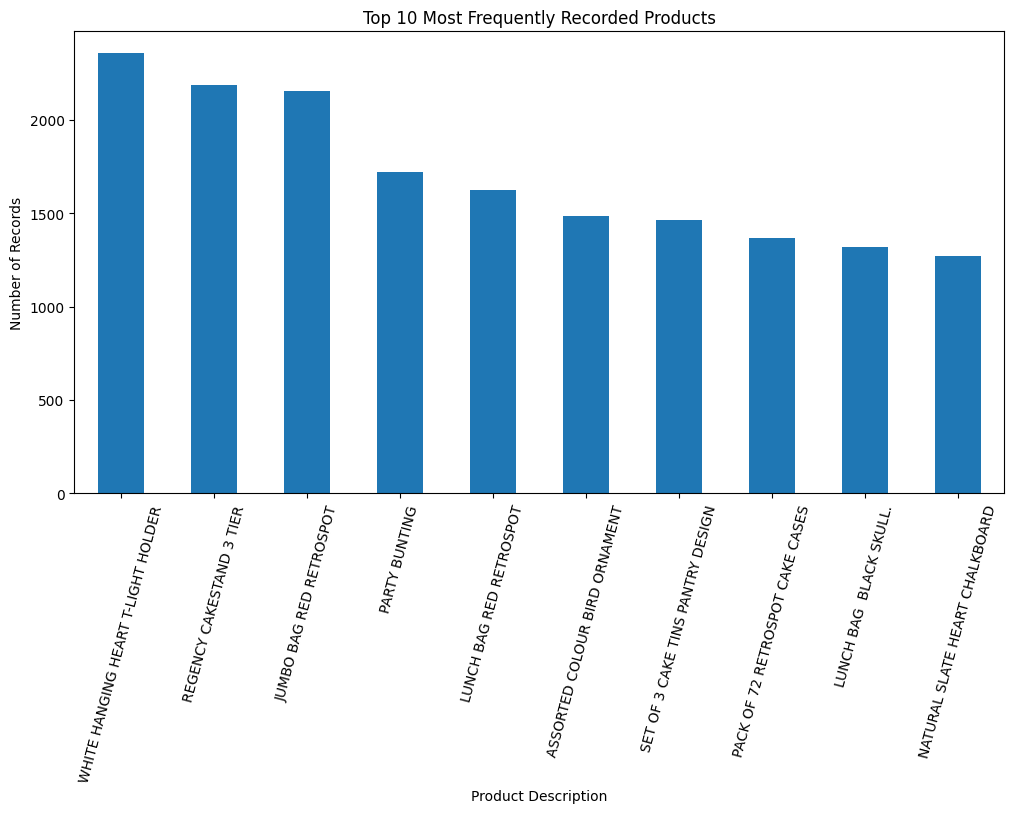

In [23]:
top_products = df['Description'].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_products.plot(kind='bar')

plt.title('Top 10 Most Frequently Recorded Products')
plt.xlabel('Product Description')
plt.ylabel('Number of Records')
plt.xticks(rotation=75)

plt.show()

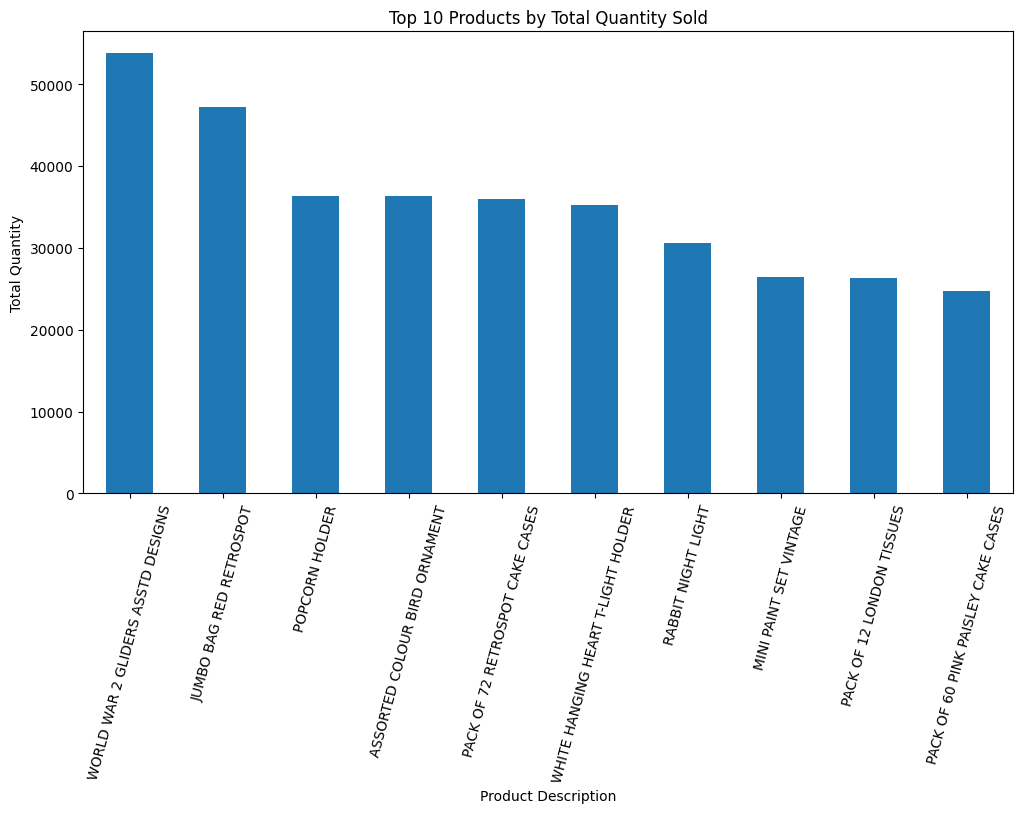

In [24]:
top_quantity_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_quantity_products.plot(kind='bar')

plt.title('Top 10 Products by Total Quantity Sold')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity')

plt.xticks(rotation=75)

plt.show()

In [25]:
df['SalesValue'] = df['Quantity'] * df['UnitPrice']

print(df[['Quantity', 'UnitPrice', 'SalesValue']].head())

   Quantity  UnitPrice  SalesValue
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [26]:
country_sales = (
    df.groupby('Country')['SalesValue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_sales)

Country
United Kingdom    8178190.244
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: SalesValue, dtype: float64


In [27]:
top_sales_products = (
    df.groupby('Description')['SalesValue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_sales_products)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: SalesValue, dtype: float64


In [28]:
sales_by_cancellation = (
    df.groupby('IsCancellation')['SalesValue']
    .agg(['count', 'sum', 'mean'])
)

sales_by_cancellation

,count,sum,mean
IsCancellation,,,
False,527387,1.063105e+07,20.157965
True,9251,-8.939797e+05,-96.636010


In [29]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [30]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('YearMonth')['SalesValue']
    .sum()
)

print(monthly_sales)

YearMonth
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     692448.520
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: SalesValue, dtype: float64


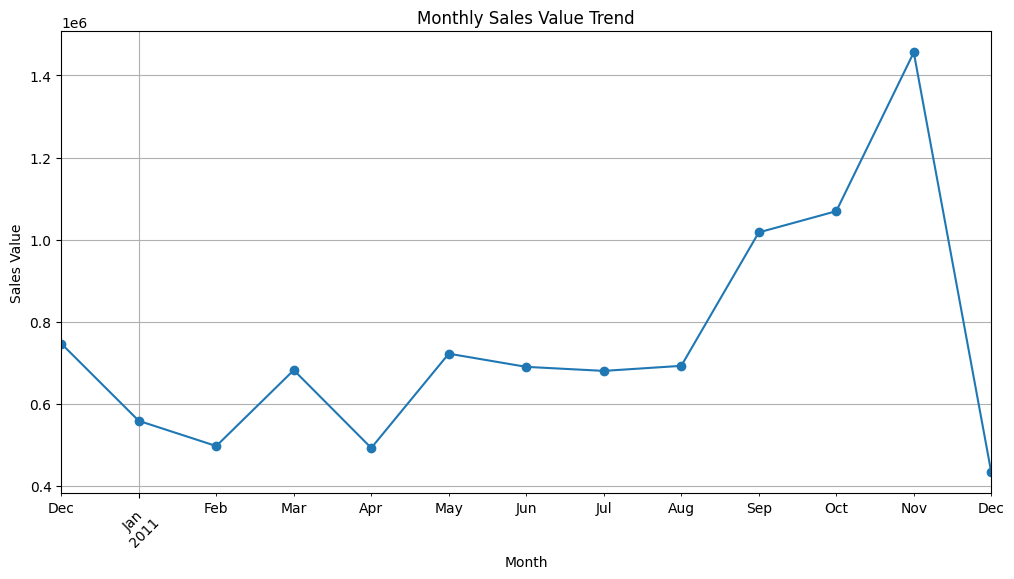

In [31]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Value Trend')
plt.xlabel('Month')
plt.ylabel('Sales Value')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [32]:
monthly_transactions = (
    df.groupby('YearMonth')['InvoiceNo']
    .nunique()
)

print(monthly_transactions)

YearMonth
2010-12    2025
2011-01    1476
2011-02    1393
2011-03    1983
2011-04    1744
2011-05    2162
2011-06    2012
2011-07    1927
2011-08    1734
2011-09    2327
2011-10    2637
2011-11    3462
2011-12    1015
Freq: M, Name: InvoiceNo, dtype: int64


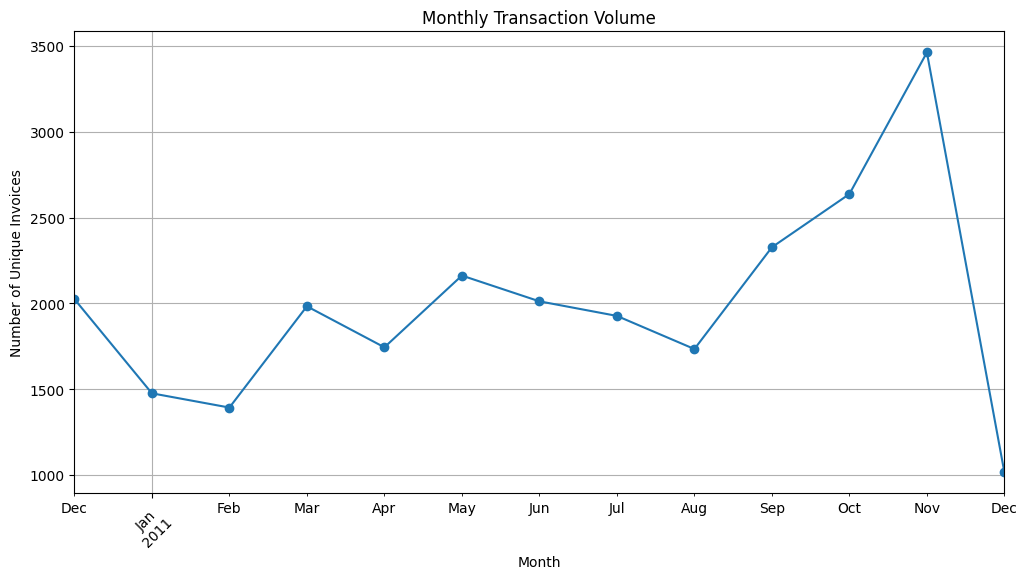

In [33]:
plt.figure(figsize=(12, 6))

monthly_transactions.plot(kind='line', marker='o')

plt.title('Monthly Transaction Volume')
plt.xlabel('Month')
plt.ylabel('Number of Unique Invoices')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [34]:
monthly_avg_value = (
    df.groupby('YearMonth')['SalesValue']
    .sum()
    /
    df.groupby('YearMonth')['InvoiceNo'].nunique()
)

print(monthly_avg_value)

YearMonth
2010-12    368.752400
2011-01    378.352683
2011-02    356.802879
2011-03    343.930398
2011-04    282.321010
2011-05    333.993571
2011-06    342.931029
2011-07    352.961594
2011-08    399.335940
2011-09    437.299820
2011-10    405.524547
2011-11    420.608261
2011-12    426.306463
Freq: M, dtype: float64


In [35]:
unique_customers = df['CustomerID'].nunique()

print("Number of unique customers:", unique_customers)

Number of unique customers: 4372


In [36]:
customer_transactions = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print(customer_transactions)

CustomerID
14911.0    248
12748.0    224
17841.0    169
14606.0    128
15311.0    118
13089.0    118
12971.0     89
14527.0     86
13408.0     81
14646.0     77
Name: InvoiceNo, dtype: int64


In [37]:
top_customers_sales = (
    df.groupby('CustomerID')['SalesValue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers_sales)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: SalesValue, dtype: float64


In [38]:
missing_customer = df['CustomerID'].isna().sum()

print("Transactions without CustomerID:", missing_customer)
print("Percentage without CustomerID:",
      round((missing_customer / len(df)) * 100, 2), "%")

Transactions without CustomerID: 135034
Percentage without CustomerID: 25.16 %


In [39]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nNumerical columns:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Number of rows: 536638
Number of columns: 11

Numerical columns:
['Quantity', 'UnitPrice', 'CustomerID', 'SalesValue']

Categorical columns:
['InvoiceNo', 'StockCode', 'Description', 'Country']

Total missing values:
136489


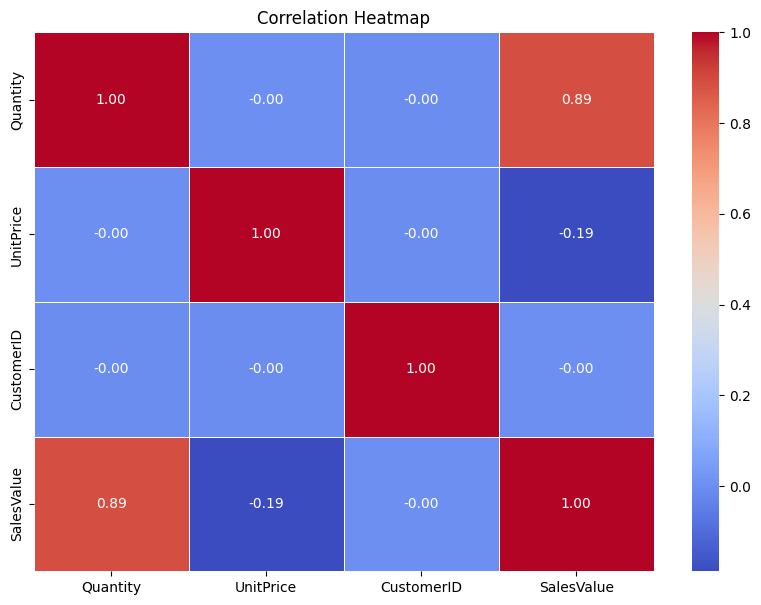

In [40]:
plt.figure(figsize=(10, 7))

correlation = df[['Quantity', 'UnitPrice', 'CustomerID', 'SalesValue']].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

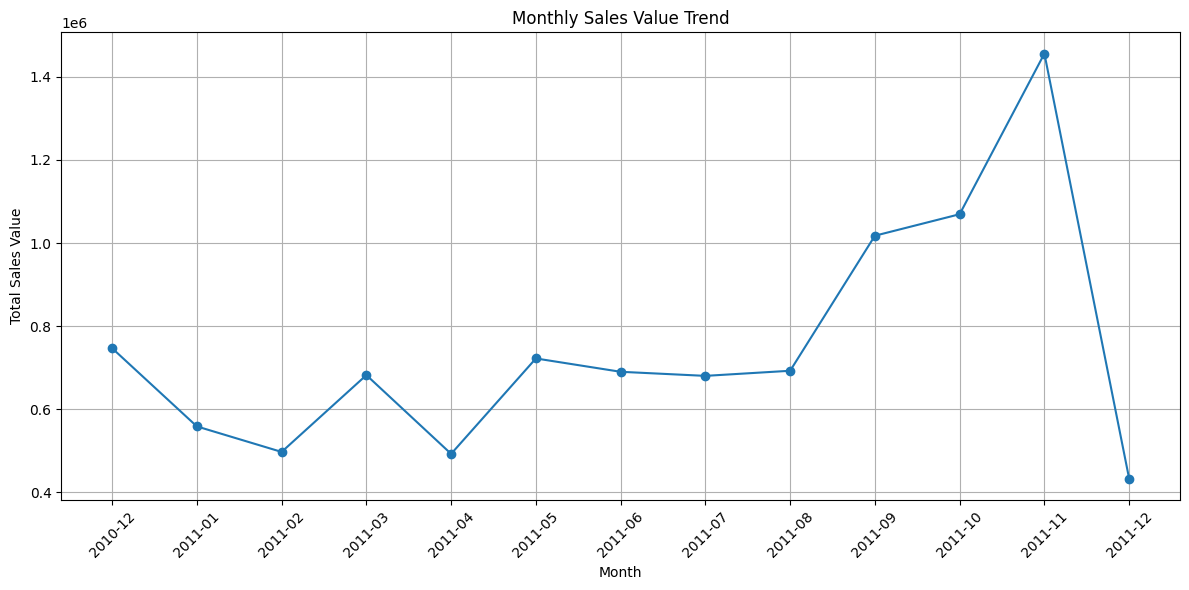

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Value Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

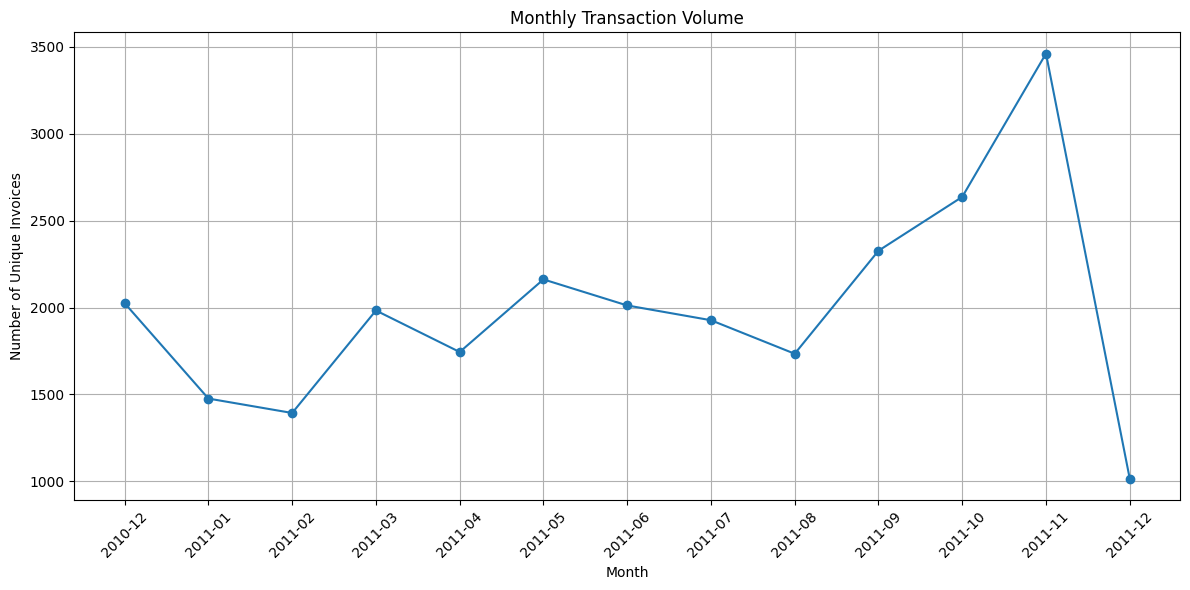

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values,
    marker='o'
)

plt.title('Monthly Transaction Volume')
plt.xlabel('Month')
plt.ylabel('Number of Unique Invoices')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

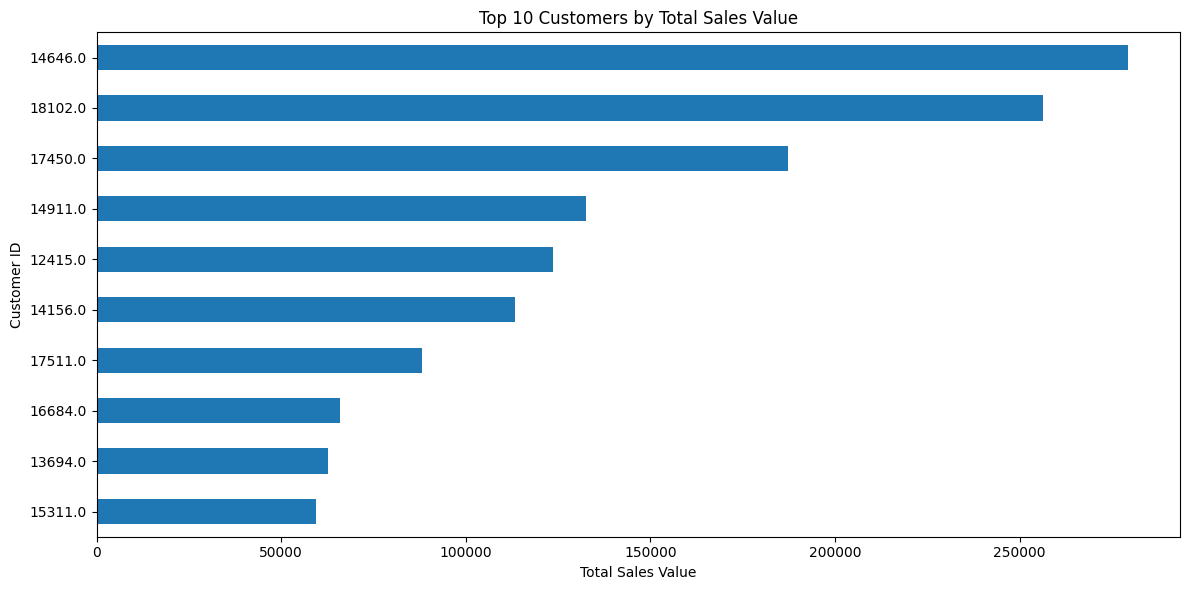

In [43]:
plt.figure(figsize=(12, 6))

top_customers_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Total Sales Value')
plt.xlabel('Total Sales Value')
plt.ylabel('Customer ID')

plt.tight_layout()
plt.show()

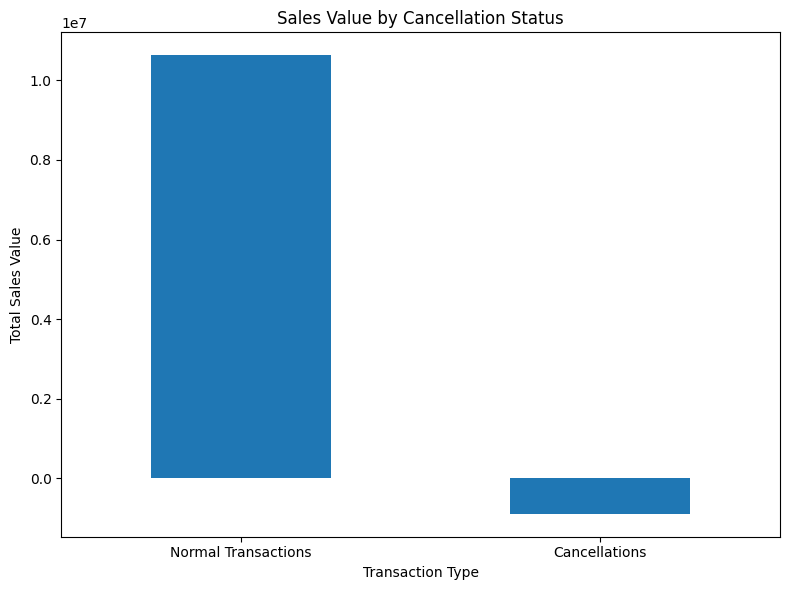

In [44]:
plt.figure(figsize=(8, 6))

cancellation_sales = df.groupby('IsCancellation')['SalesValue'].sum()

cancellation_sales.index = ['Normal Transactions', 'Cancellations']

cancellation_sales.plot(kind='bar')

plt.title('Sales Value by Cancellation Status')
plt.xlabel('Transaction Type')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

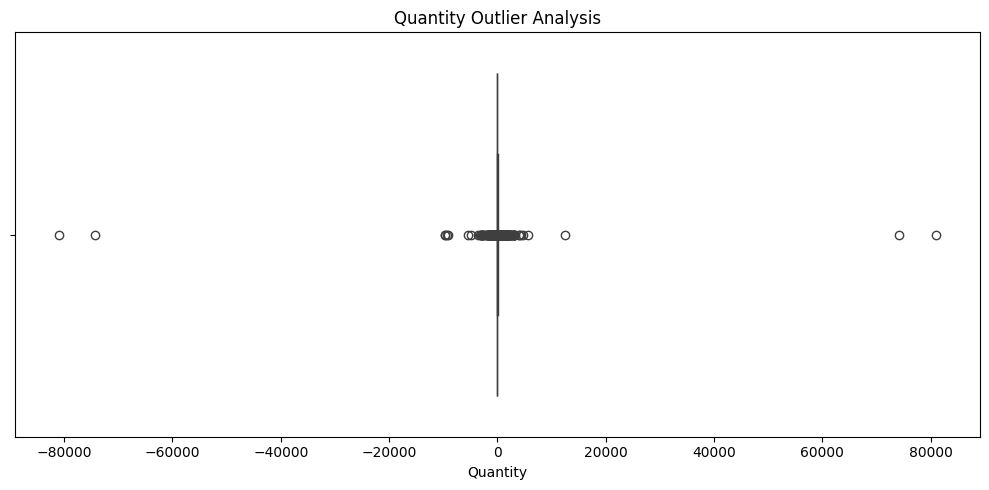

In [45]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Quantity'])

plt.title('Quantity Outlier Analysis')
plt.xlabel('Quantity')

plt.tight_layout()
plt.show()

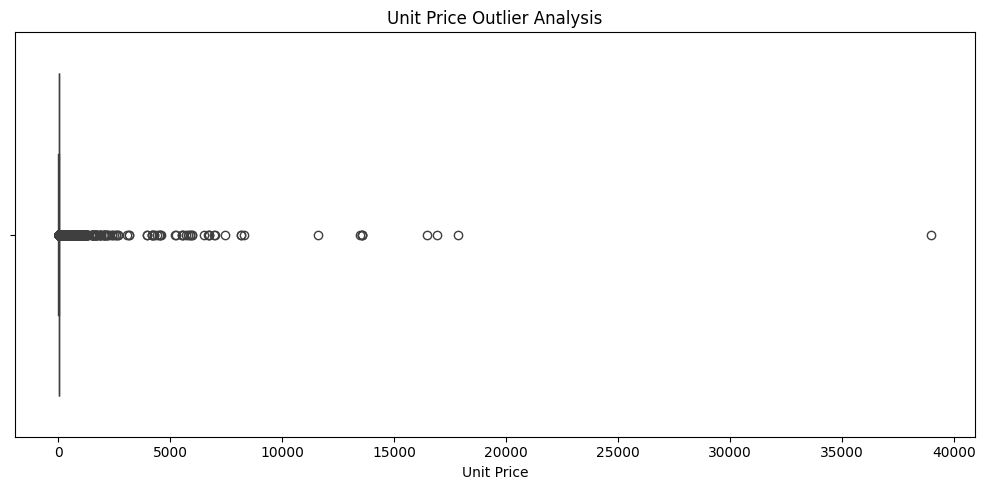

In [46]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['UnitPrice'])

plt.title('Unit Price Outlier Analysis')
plt.xlabel('Unit Price')

plt.tight_layout()
plt.show()